# 01 - Exploratory Data Analysis (EDA)
### Chronic Kidney Disease Prediction Project

**Dataset:** UCI Chronic Kidney Disease — 400 patients, 25 features  
**Objective:** Understand the raw data *before* touching any preprocessing or modelling.

---

### What this notebook covers

| Section | Purpose |
|---------|---------|
| 1. Setup | Imports, paths, style |
| 2. Load Data | Read raw CSV, inspect shape and dtypes |
| 3. Statistical Summary | Describe numerical features |
| 4. Target Distribution | Class balance — CKD vs Not CKD |
| 5. Missing Values | Which features have gaps and how severe |
| 6. Dirty Values | Tab/space contamination in categoricals |
| 7. Numerical Distributions | Histograms + KDE per feature |
| 8. Categorical Distributions | Count plots per category |
| 9. Correlation Heatmap | Multicollinearity between numericals |
| 10. Feature vs Target | KDE plots — class separation per feature |
| 11. Box Plots | Outlier detection per feature by class |
| 12. EDA Summary | Key findings that drive preprocessing decisions |

> All plots are saved automatically to `../visualizations/`


## 1. Setup - Imports & Configuration

In [1]:
import os
print(os.getcwd())

c:\Users\HP\Desktop\ml-kidney\notebooks


In [2]:
import sys
from pathlib import Path

SRC_DIR = Path("../src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(SRC_DIR)
print(SRC_DIR.exists())

C:\Users\HP\Desktop\ml-kidney\src
True


In [3]:
import config

print(config.__file__)

C:\Users\HP\Desktop\ml-kidney\src\config.py


In [4]:
import sys

if "config" in sys.modules:
    del sys.modules["config"]

import config

print(config.__file__)
print(hasattr(config, "RAW_DATA_PATH"))
print(config.RAW_DATA_PATH)

C:\Users\HP\Desktop\ml-kidney\src\config.py
True
C:\Users\HP\Desktop\ml-kidney\data\kidney_disease.csv


In [6]:
# Standard library
import sys
import warnings
from pathlib import Path

# Add src/ to Python path
SRC_DIR = Path("../src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

warnings.filterwarnings("ignore")

# Data & numerics
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde

# Project config
from config import (
    RAW_DATA_PATH,
    NUMERICAL_COLS,
    CATEGORICAL_COLS,
    TARGET_COLUMN,
    VIZ_DIR,
    FIG_DPI,
    PLOT_STYLE,
    PALETTE,
    COLOR_CKD,
    COLOR_NOTCKD,
)

# Apply consistent style
plt.style.use(PLOT_STYLE)
sns.set_palette(PALETTE)

# Ensure output folder exists
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("Imports successful")
print(f"Dataset path: {RAW_DATA_PATH}")
print(f"Visualizations will be saved to: {VIZ_DIR}")

Imports successful
Dataset path: C:\Users\HP\Desktop\ml-kidney\data\kidney_disease.csv
Visualizations will be saved to: C:\Users\HP\Desktop\ml-kidney\visualizations


## 2. Load Raw Data

We load the raw CSV *without* any preprocessing so we can see the data
exactly as it came from the source - dirty values, wrong dtypes, and all.


In [7]:
# Load raw CSV and apply consistent column naming via config
# Using RAW_DATA_PATH from config means no hardcoded paths — works on any machine
from preprocess import load_raw_data, coerce_types

df = load_raw_data()

print(f"Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
df.head()


Dataset shape : 400 rows × 25 columns
Memory usage  : 354.4 KB



,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [8]:
# Inspect dtypes — this reveals which columns are stored incorrectly
# packed_cell_volume, white_blood_cell_count, red_blood_cell_count should be
# numeric but will show as 'object' due to non-numeric characters in the raw CSV
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

## 3. Statistical Summary

`describe()` gives us a quick feel for:
- **Range** — min/max reveal implausible outliers (e.g. potassium = 47?)
- **Mean vs Median** — large gap signals skewness
- **Std deviation** — high std relative to mean = high variance feature


In [9]:
# Force numeric conversion first so describe() works on all intended columns
df_num = coerce_types(df)

# Round to 2 decimal places for readability
df_num[NUMERICAL_COLS].describe().round(2)

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,391.00,388.00,353.00,354.00,351.00,356.00,381.00,383.00,313.00,312.00,348.00,329.00,294.00,269.00
mean,51.48,76.47,1.02,1.02,0.45,148.04,57.43,3.07,137.53,4.63,12.53,38.88,8406.12,4.71
std,17.17,13.68,0.01,1.35,1.10,79.28,50.50,5.74,10.41,3.19,2.91,8.99,2944.47,1.03
min,2.00,50.00,1.00,0.00,0.00,22.00,1.50,0.40,4.50,2.50,3.10,9.00,2200.00,2.10
25%,42.00,70.00,1.01,0.00,0.00,99.00,27.00,0.90,135.00,3.80,10.30,32.00,6500.00,3.90
50%,55.00,80.00,1.02,0.00,0.00,121.00,42.00,1.30,138.00,4.40,12.65,40.00,8000.00,4.80
75%,64.50,80.00,1.02,2.00,0.00,163.00,66.00,2.80,142.00,4.90,15.00,45.00,9800.00,5.40
max,90.00,180.00,1.02,5.00,5.00,490.00,391.00,76.00,163.00,47.00,17.80,54.00,26400.00,8.00


## 4. Target Variable — Class Distribution

Understanding class balance is critical before modelling.

- **Imbalanced classes** → accuracy metric becomes misleading
  (e.g. predicting all CKD gives 62% accuracy but is clinically useless)
- **Mild imbalance** (like ours) → manageable with stratified splitting
- **Severe imbalance** (>90/10) → requires oversampling (SMOTE) or class weights

Also note the dirty `'ckd\t'` entries — these will be cleaned in preprocessing.


Raw target value counts:
class
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64



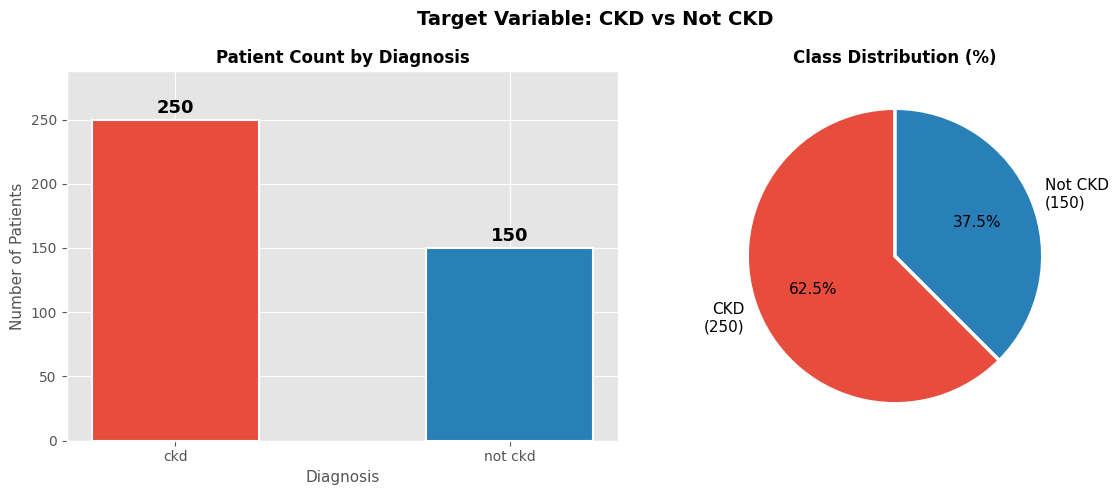

CKD     : 250 patients  (62.5%)
Not CKD : 150 patients  (37.5%)

Class ratio  : 1.67:1  (mild imbalance — manageable with stratify=True)


In [10]:
# Raw counts — shows the dirty 'ckd\t' entries before cleaning
print("Raw target value counts:")
print(df[TARGET_COLUMN].value_counts())
print()

# Clean version for plotting — strip whitespace, normalise labels
clean_target = (
    df[TARGET_COLUMN]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"ckd\t": "ckd", "notckd": "not ckd"})
)
counts = clean_target.value_counts()

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bar_colors = [COLOR_CKD, COLOR_NOTCKD]
bars = axes[0].bar(counts.index, counts.values,
                   color=bar_colors, edgecolor="white", linewidth=1.5, width=0.5)

# Add count labels above each bar
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(val),
        ha="center", va="bottom", fontsize=13, fontweight="bold",
    )

axes[0].set_title("Patient Count by Diagnosis", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Diagnosis", fontsize=11)
axes[0].set_ylabel("Number of Patients", fontsize=11)
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[f"CKD\n({counts['ckd']})", f"Not CKD\n({counts['not ckd']})"],
    autopct="%1.1f%%",
    colors=bar_colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 11},
)
axes[1].set_title("Class Distribution (%)", fontsize=12, fontweight="bold")

plt.suptitle("Target Variable: CKD vs Not CKD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(VIZ_DIR / "01_class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print(f"CKD     : {counts.get('ckd', 0):>3} patients  ({counts.get('ckd',0)/len(df)*100:.1f}%)")
print(f"Not CKD : {counts.get('not ckd', 0):>3} patients  ({counts.get('not ckd',0)/len(df)*100:.1f}%)")
print(f"\nClass ratio  : {counts.max() / counts.min():.2f}:1  (mild imbalance — manageable with stratify=True)")


## 5. Missing Values Analysis

High missingness affects which imputation strategy to use:
- **> 30% missing** - random-sample imputation (mean would distort distribution)
- **< 15% missing** - mode imputation safe for categoricals
- **> 50% missing** - consider dropping the feature entirely (none here)


In [11]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(1)

missing_df = (
    pd.DataFrame({"Missing Count": missing_count, "Missing (%)": missing_pct})
    .query("`Missing Count` > 0")
    .sort_values("Missing (%)", ascending=False)
)

print(f"{len(missing_df)} out of {len(df.columns)} features have missing values:\n")
print(missing_df.to_string())
print(f"\nTotal missing cells : {missing_count.sum()} / {df.shape[0] * df.shape[1]} ({missing_count.sum()/(df.shape[0]*df.shape[1])*100:.1f}%)")


24 out of 25 features have missing values:

                         Missing Count  Missing (%)
red_blood_cells                    152         38.0
red_blood_cell_count               131         32.8
white_blood_cell_count             106         26.5
potassium                           88         22.0
sodium                              87         21.8
packed_cell_volume                  71         17.8
pus_cell                            65         16.2
haemoglobin                         52         13.0
sugar                               49         12.2
specific_gravity                    47         11.8
albumin                             46         11.5
blood_glucose_random                44         11.0
blood_urea                          19          4.8
serum_creatinine                    17          4.2
blood_pressure                      12          3.0
age                                  9          2.2
pus_cell_clumps                      4          1.0
bacteria            

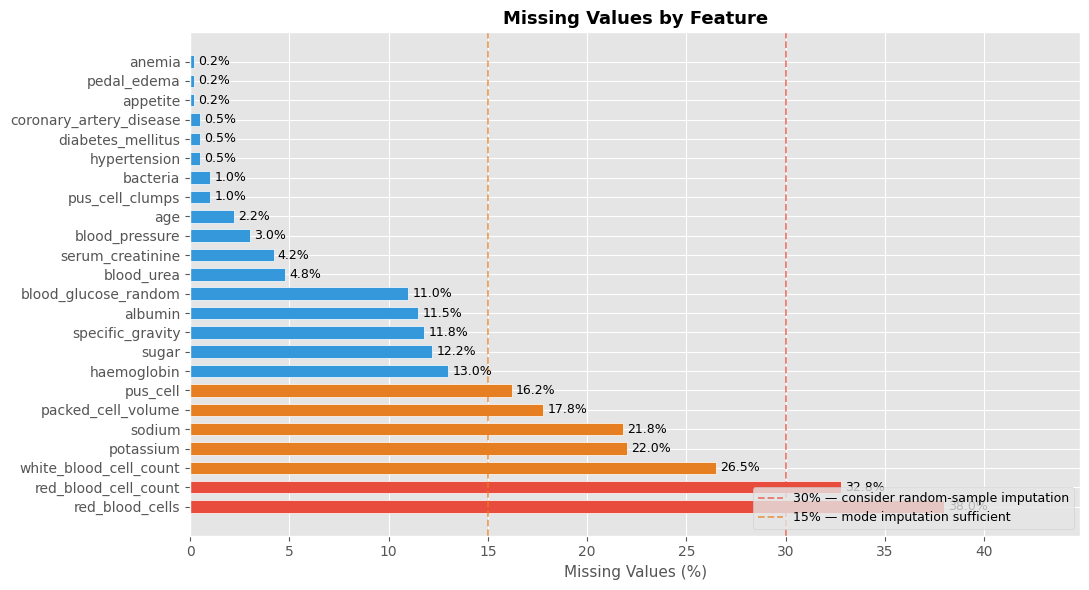

In [12]:
# Horizontal bar chart — coloured by severity
fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = [
    "#e74c3c" if p > 30 else   # red   — high missingness
    "#e67e22" if p > 15 else   # amber — moderate
    "#3498db"                   # blue  — low
    for p in missing_df["Missing (%)"]
]

bars = ax.barh(missing_df.index, missing_df["Missing (%)"],
               color=bar_colors, edgecolor="white", height=0.65)

# Value labels on each bar
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

# Reference lines
ax.axvline(30, color="#e74c3c", linestyle="--", linewidth=1.3,
           alpha=0.7, label="30% — consider random-sample imputation")
ax.axvline(15, color="#e67e22", linestyle="--", linewidth=1.3,
           alpha=0.7, label="15% — mode imputation sufficient")

ax.set_xlabel("Missing Values (%)", fontsize=11)
ax.set_title("Missing Values by Feature", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0, max(missing_df["Missing (%)"]) * 1.18)

plt.tight_layout()
plt.savefig(VIZ_DIR / "02_missing_values.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 6. Dirty Values in Categorical Columns

Some categorical columns contain tab characters (`\t`) or extra spaces
as prefixes/suffixes. Without cleaning these would appear as extra unique
categories, breaking encoding and analysis.


In [14]:
print("Unique values per categorical column (raw — shows dirty entries):\n")

# Temporarily include target for inspection
all_cat = CATEGORICAL_COLS + [TARGET_COLUMN]

for col in all_cat:
    unique_vals = df[col].unique()
    # Flag dirty values visually
    flagged = [
        f"'{v}' ⚠" if isinstance(v, str) and (v.startswith("\t") or v.startswith(" ") or v.endswith("\t"))
        else f"'{v}'"
        for v in unique_vals
        if v is not None and str(v) != "nan"
    ]
    print(f"  {col:<30} - {', '.join(flagged)}")


Unique values per categorical column (raw — shows dirty entries):

  red_blood_cells                - 'normal', 'abnormal'
  pus_cell                       - 'normal', 'abnormal'
  pus_cell_clumps                - 'notpresent', 'present'
  bacteria                       - 'notpresent', 'present'
  hypertension                   - 'yes', 'no'
  diabetes_mellitus              - 'yes', 'no', ' yes' ⚠, '	no' ⚠, '	yes' ⚠
  coronary_artery_disease        - 'no', 'yes', '	no' ⚠
  appetite                       - 'good', 'poor'
  pedal_edema                    - 'no', 'yes'
  anemia                         - 'no', 'yes'
  class                          - 'ckd', 'ckd	' ⚠, 'notckd'


## 7. Numerical Feature Distributions

Histograms with KDE (Kernel Density Estimate) overlays reveal:
- **Skewness** — right-skewed features may need log transformation
- **Bimodality** — two peaks can indicate strong class separation
- **Outliers** — extreme values far from the bulk of the distribution

These insights guide imputation strategy and feature engineering decisions.


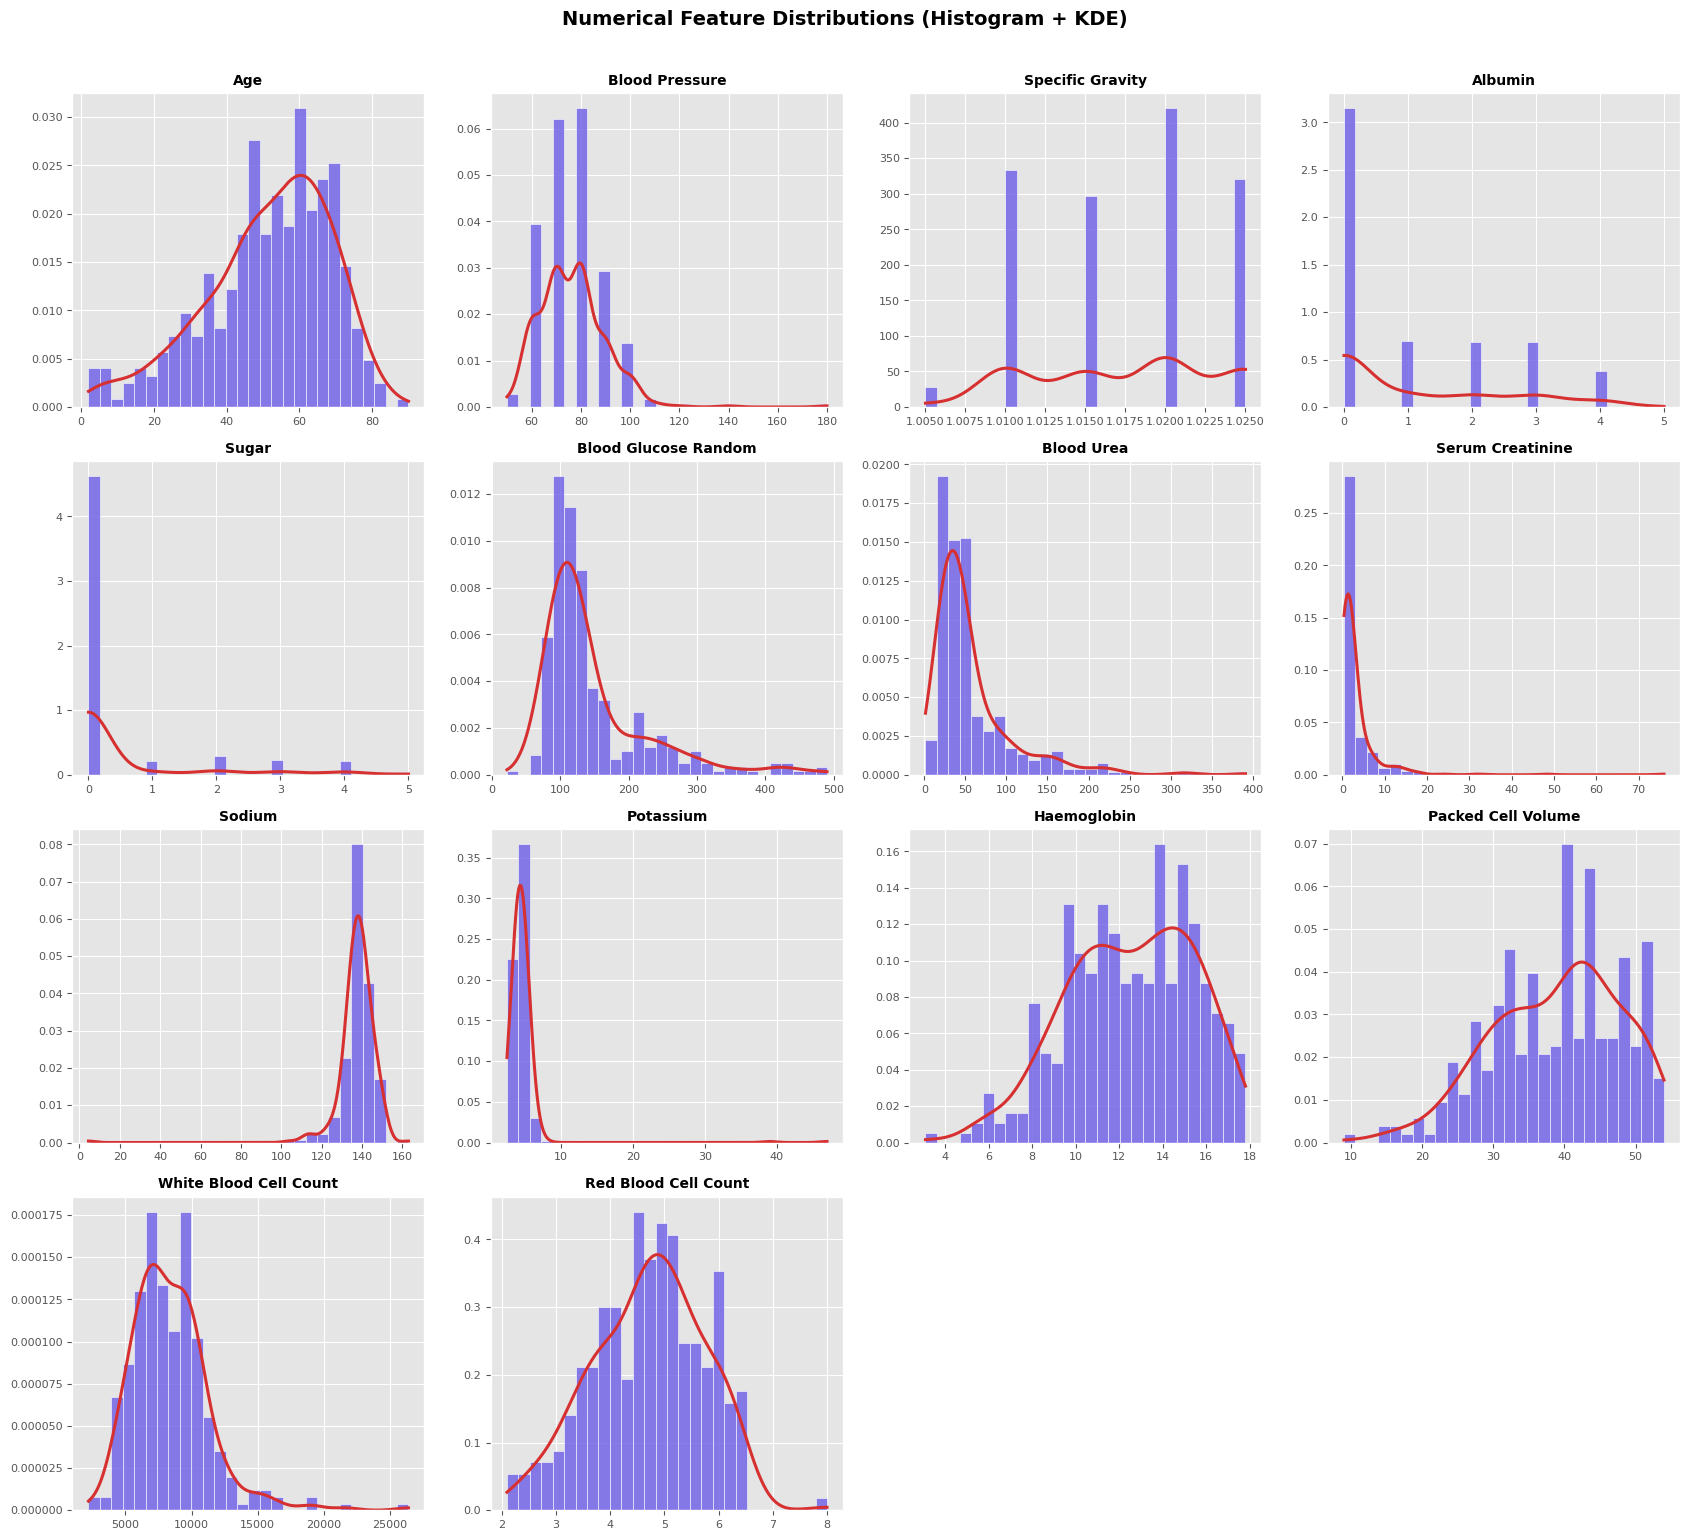

In [15]:
# Force numeric types for the 3 object columns before plotting
df_plot = coerce_types(df)

n_cols  = 4
n_rows  = -(-len(NUMERICAL_COLS) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, n_rows * 3.8))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    data = df_plot[col].dropna()

    # Histogram
    axes[i].hist(data, bins=28, color="#6c5ce7",
                 edgecolor="white", alpha=0.80, density=True)

    # KDE overlay — shows the smooth underlying distribution
    if len(data) > 1:
        kde  = gaussian_kde(data)
        x    = np.linspace(data.min(), data.max(), 300)
        axes[i].plot(x, kde(x), color="#d63031", linewidth=2.2, label="KDE")

    axes[i].set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=8)

# Hide any unused subplot slots
for j in range(len(NUMERICAL_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Numerical Feature Distributions (Histogram + KDE)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(VIZ_DIR / "03_numerical_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 8. Categorical Feature Distributions

Count plots reveal:
- **Label frequencies** — highly dominant labels contribute less discriminating power
- **Dirty values** — tab-prefixed labels appearing as separate bars confirm Section 6 findings


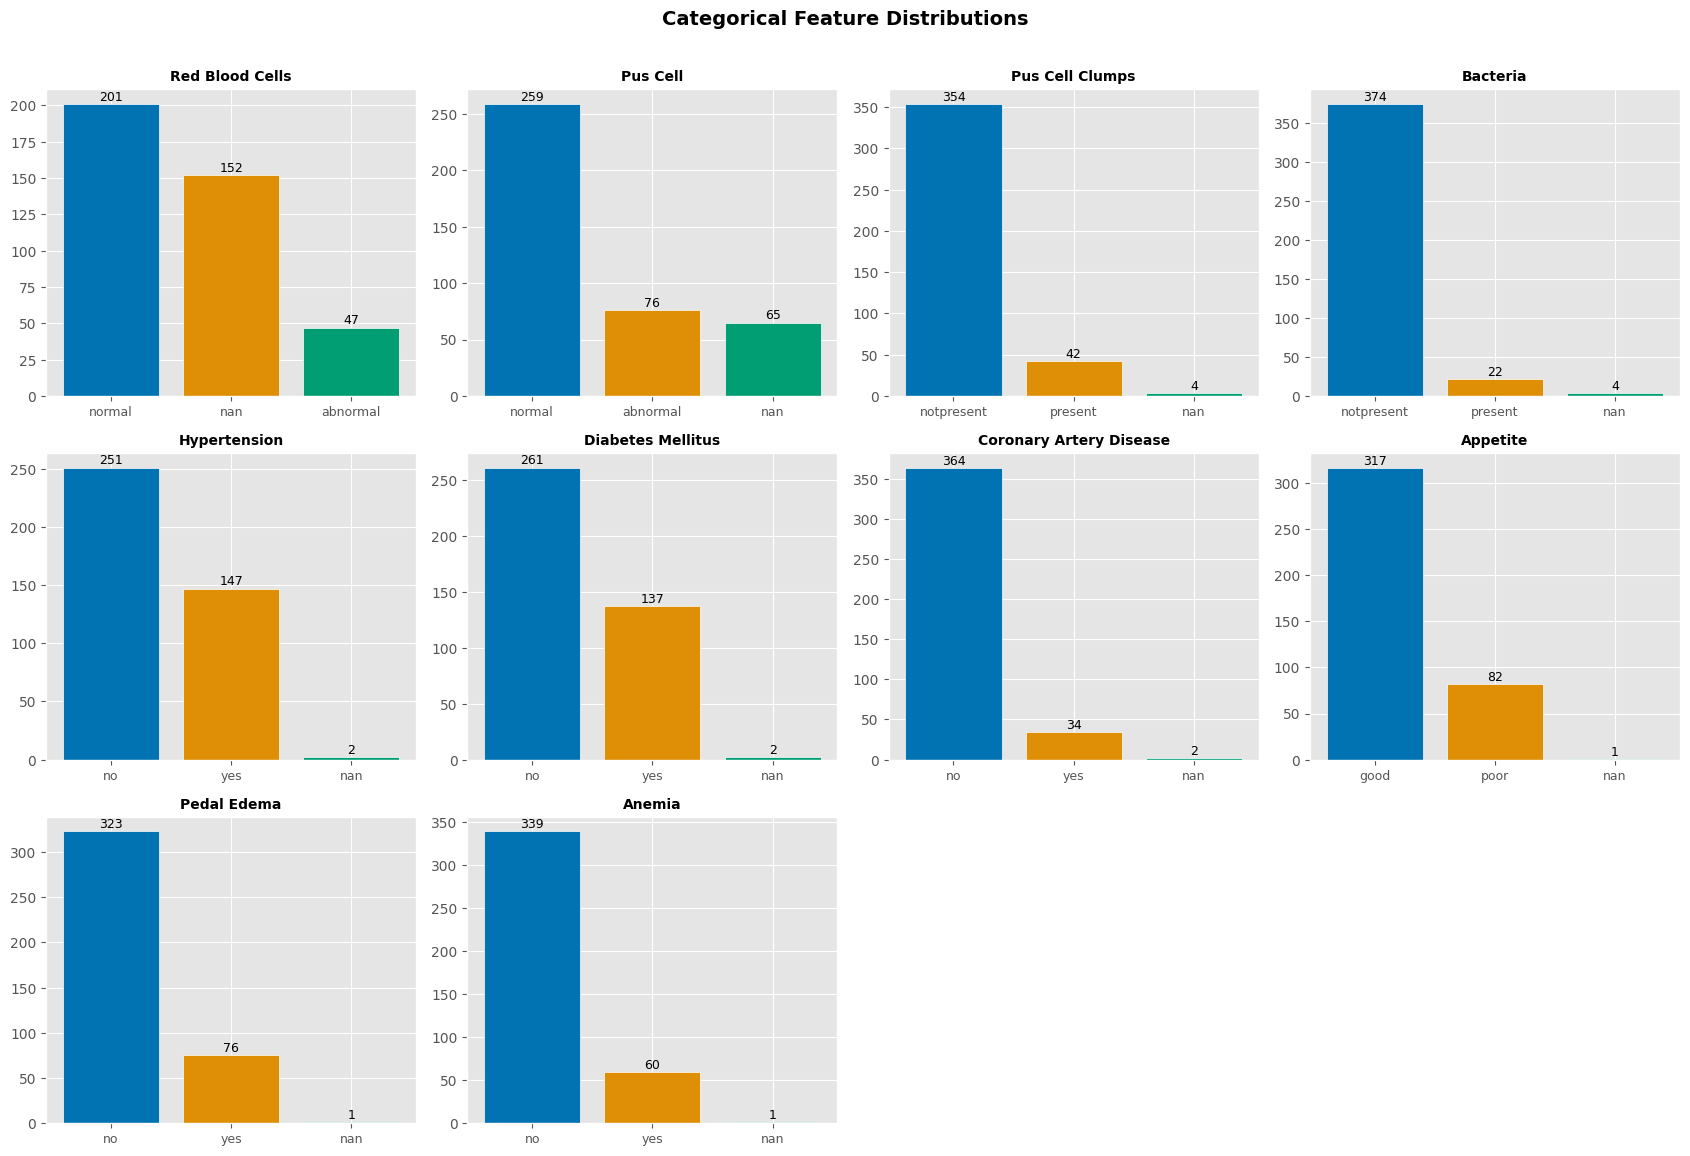

In [16]:
n_cols = 4
n_rows = -(-len(CATEGORICAL_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, n_rows * 3.8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    # Strip whitespace so dirty values don't appear as extra bars here
    clean_col = df[col].astype(str).str.strip().str.lower()
    vc        = clean_col.value_counts()
    palette   = sns.color_palette(PALETTE, len(vc))

    bars = axes[i].bar(vc.index, vc.values, color=palette, edgecolor="white")

    # Count labels above bars
    for bar, val in zip(bars, vc.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=9,
        )

    axes[i].set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", labelsize=9)

for j in range(len(CATEGORICAL_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Categorical Feature Distributions",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(VIZ_DIR / "04_categorical_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 9. Correlation Heatmap — Numerical Features

Pearson correlation matrix reveals:
- **Multicollinearity** — highly correlated features (|r| > 0.7) carry redundant information
  (e.g. haemoglobin ↔ packed_cell_volume: r ≈ 0.90)
- **Feature-target correlation** — features strongly correlated with `class`
  are likely strong predictors
- **Negative correlations** — e.g. albumin negatively correlated with haemoglobin

The upper triangle is masked to avoid redundancy.


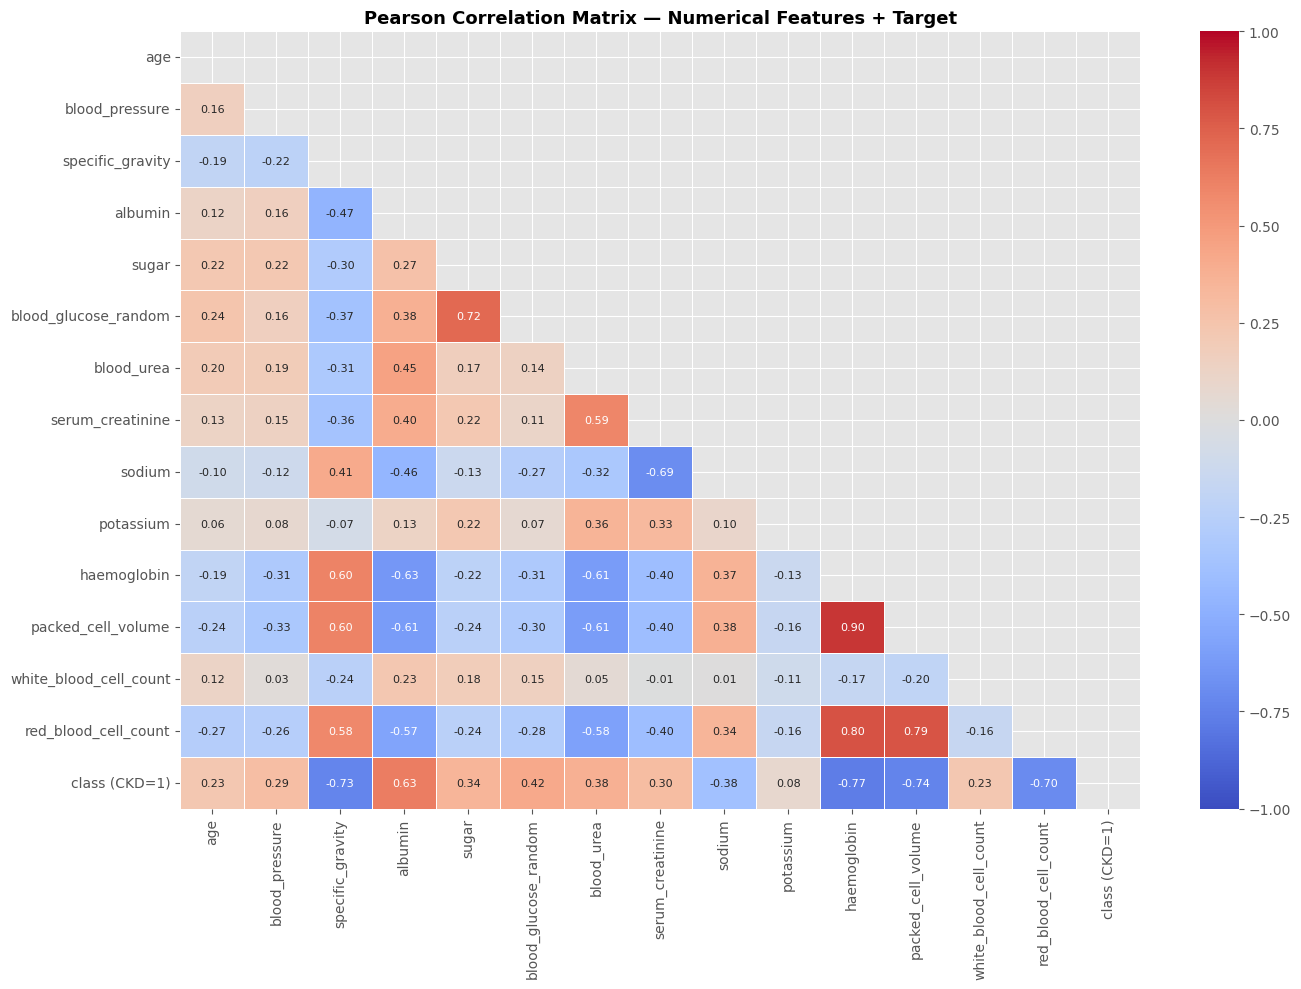

Top feature correlations with CKD diagnosis (absolute value):
  haemoglobin                    r = 0.769  ↓ CKD
  packed_cell_volume             r = 0.741  ↓ CKD
  specific_gravity               r = 0.732  ↓ CKD
  red_blood_cell_count           r = 0.699  ↓ CKD
  albumin                        r = 0.627  ↑ CKD
  blood_glucose_random           r = 0.420  ↑ CKD
  blood_urea                     r = 0.381  ↑ CKD
  sodium                         r = 0.376  ↓ CKD
  sugar                          r = 0.344  ↑ CKD
  serum_creatinine               r = 0.300  ↑ CKD
  blood_pressure                 r = 0.294  ↑ CKD
  white_blood_cell_count         r = 0.232  ↑ CKD
  age                            r = 0.227  ↑ CKD
  potassium                      r = 0.085  ↑ CKD


In [17]:
df_num = coerce_types(df)

# Include a clean numeric target for correlation with features
clean_target = (
    df[TARGET_COLUMN]
    .astype(str).str.strip().str.lower()
    .replace({"ckd\t": "ckd", "notckd": "not ckd"})
    .map({"ckd": 1, "not ckd": 0})
)
df_corr = df_num[NUMERICAL_COLS].copy()
df_corr["class (CKD=1)"] = clean_target

corr = df_corr.corr()

# Mask upper triangle (mirror of lower — redundant)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title(
    "Pearson Correlation Matrix — Numerical Features + Target",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(VIZ_DIR / "05_correlation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Print top correlations with the target
print("Top feature correlations with CKD diagnosis (absolute value):")
target_corr = corr["class (CKD=1)"].drop("class (CKD=1)").abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = "↑ CKD" if corr["class (CKD=1)"][feat] > 0 else "↓ CKD"
    print(f"  {feat:<30} r = {val:.3f}  {direction}")


## 10. Feature vs Target - KDE Separation Plots

Overlapping KDE curves for CKD (red) vs Not CKD (blue) per feature.

**How to read:**
- **Wide separation** between curves → feature is highly predictive
- **Overlapping curves** → feature adds little discriminating power alone
- **Bimodal distribution** → strong class signal

Features with clear separation are the ones the models will rely on most.


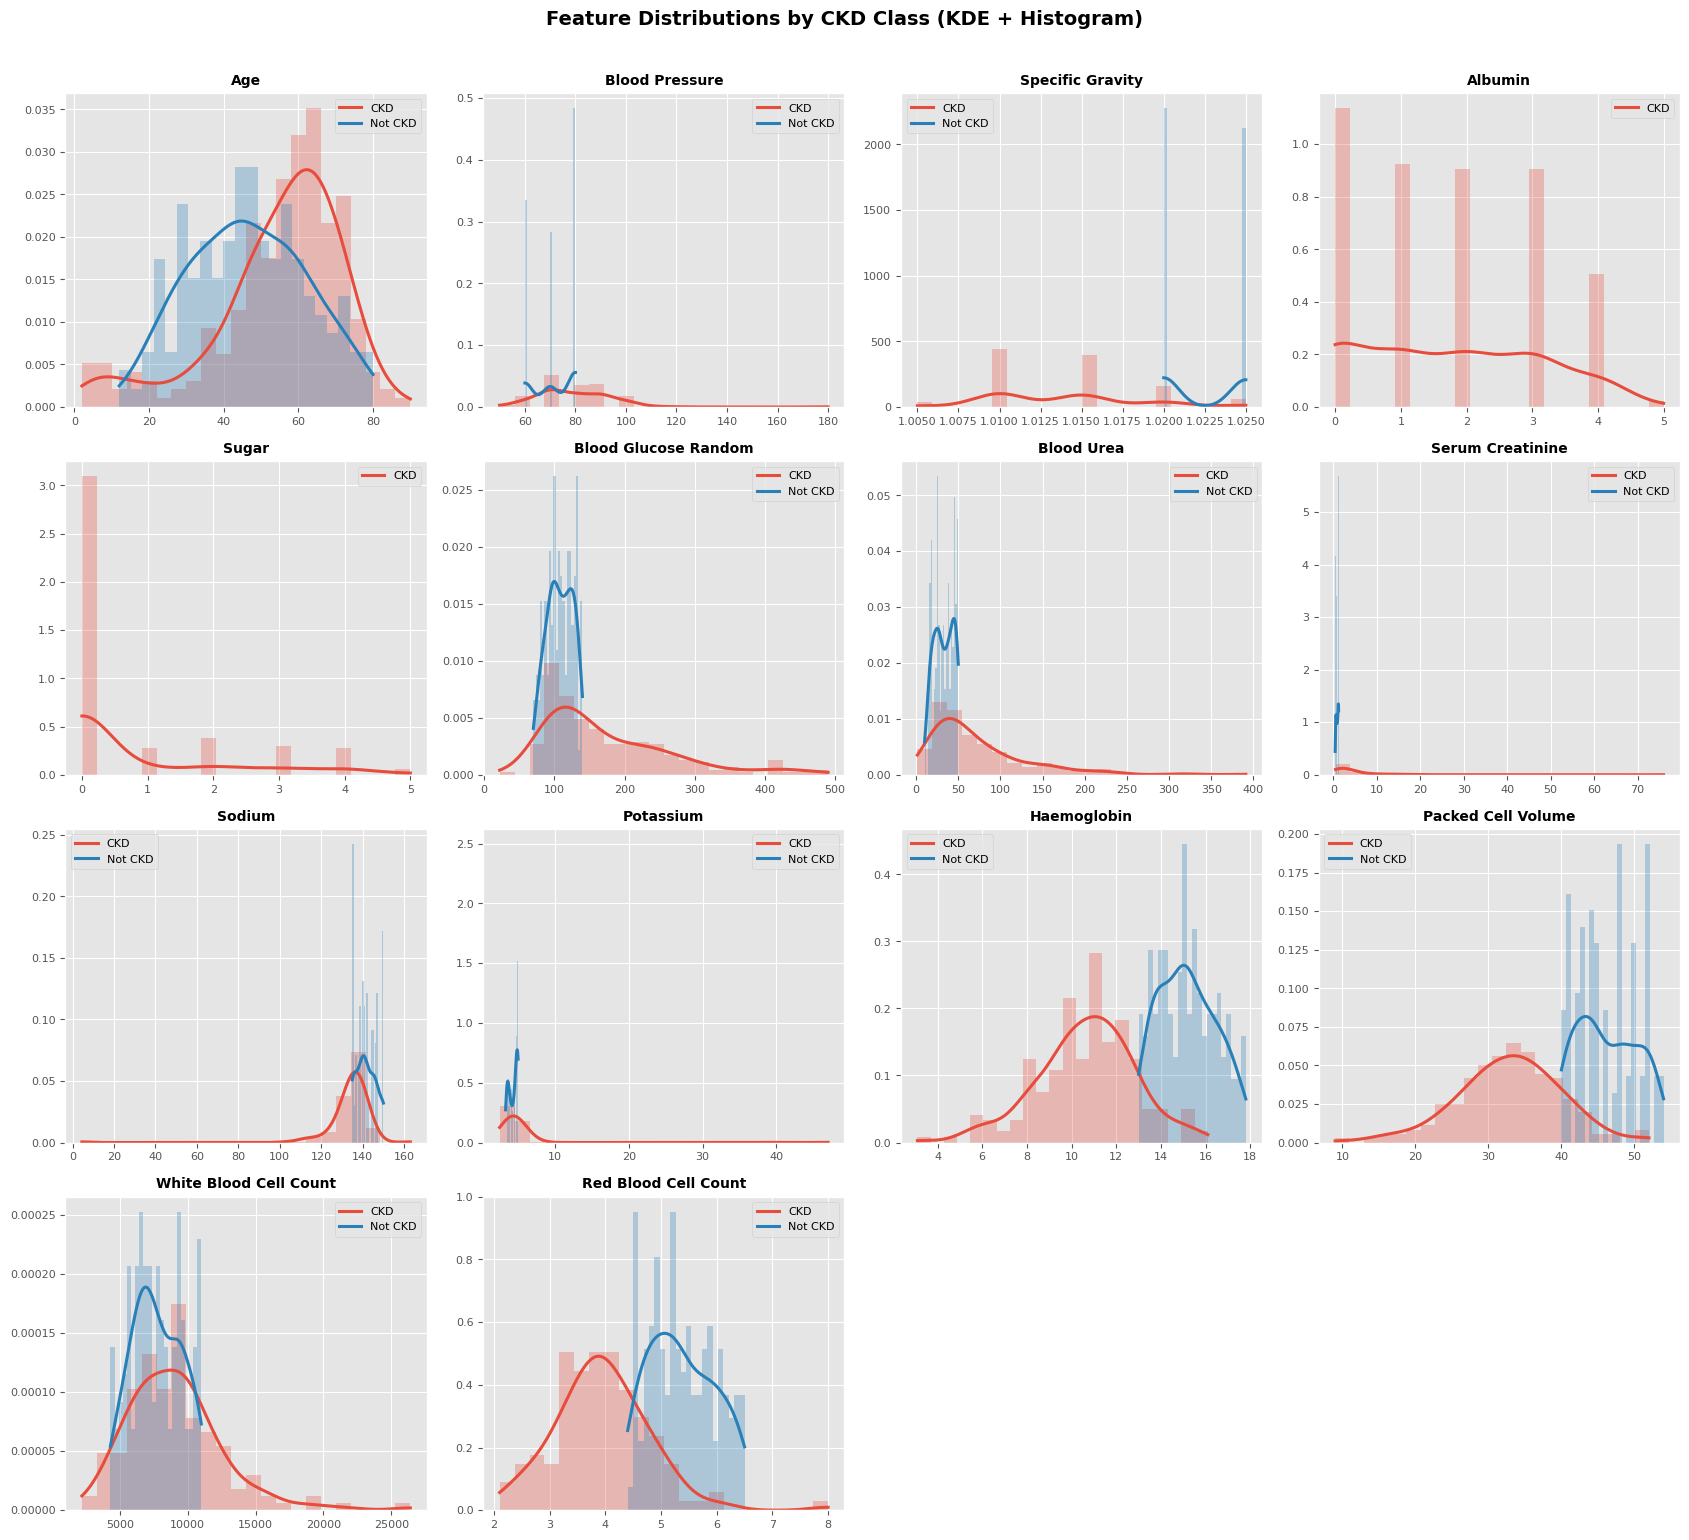

In [19]:
df_plot  = coerce_types(df)
df_plot["_class"] = (
    df[TARGET_COLUMN]
    .astype(str).str.strip().str.lower()
    .replace({"ckd\t": "ckd", "notckd": "not ckd"})
)

n_cols = 4
n_rows = -(-len(NUMERICAL_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, n_rows * 3.8))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    for label, color, display in [
        ("ckd",     COLOR_CKD,    "CKD"),
        ("not ckd", COLOR_NOTCKD, "Not CKD"),
    ]:
        subset = df_plot[df_plot["_class"] == label][col].dropna()
        if len(subset) < 2 or subset.nunique() < 2:
            continue

        # Histogram (semi-transparent)
        axes[i].hist(subset, bins=22, alpha=0.30, density=True,
                     color=color)

        # KDE curve (solid)
        try:
            kde = gaussian_kde(subset)
            x = np.linspace(subset.min(), subset.max(), 300)
            axes[i].plot(x, kde(x), color=color, linewidth=2.2, label=display)
        except np.linalg.LinAlgError:
            pass

    axes[i].set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

for j in range(len(NUMERICAL_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Feature Distributions by CKD Class (KDE + Histogram)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(VIZ_DIR / "06_feature_vs_target_kde.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## 11. Box Plots - Outlier Detection by Class

Box plots show:
- **Median** - centre line inside box
- **IQR** - box spans 25th to 75th percentile
- **Whiskers** - extend to 1.5 × IQR
- **Points beyond whiskers** - outliers

Comparing CKD vs Not CKD boxes shows:
- How well the classes separate on each feature
- Which features have extreme outliers (e.g. potassium, serum creatinine)


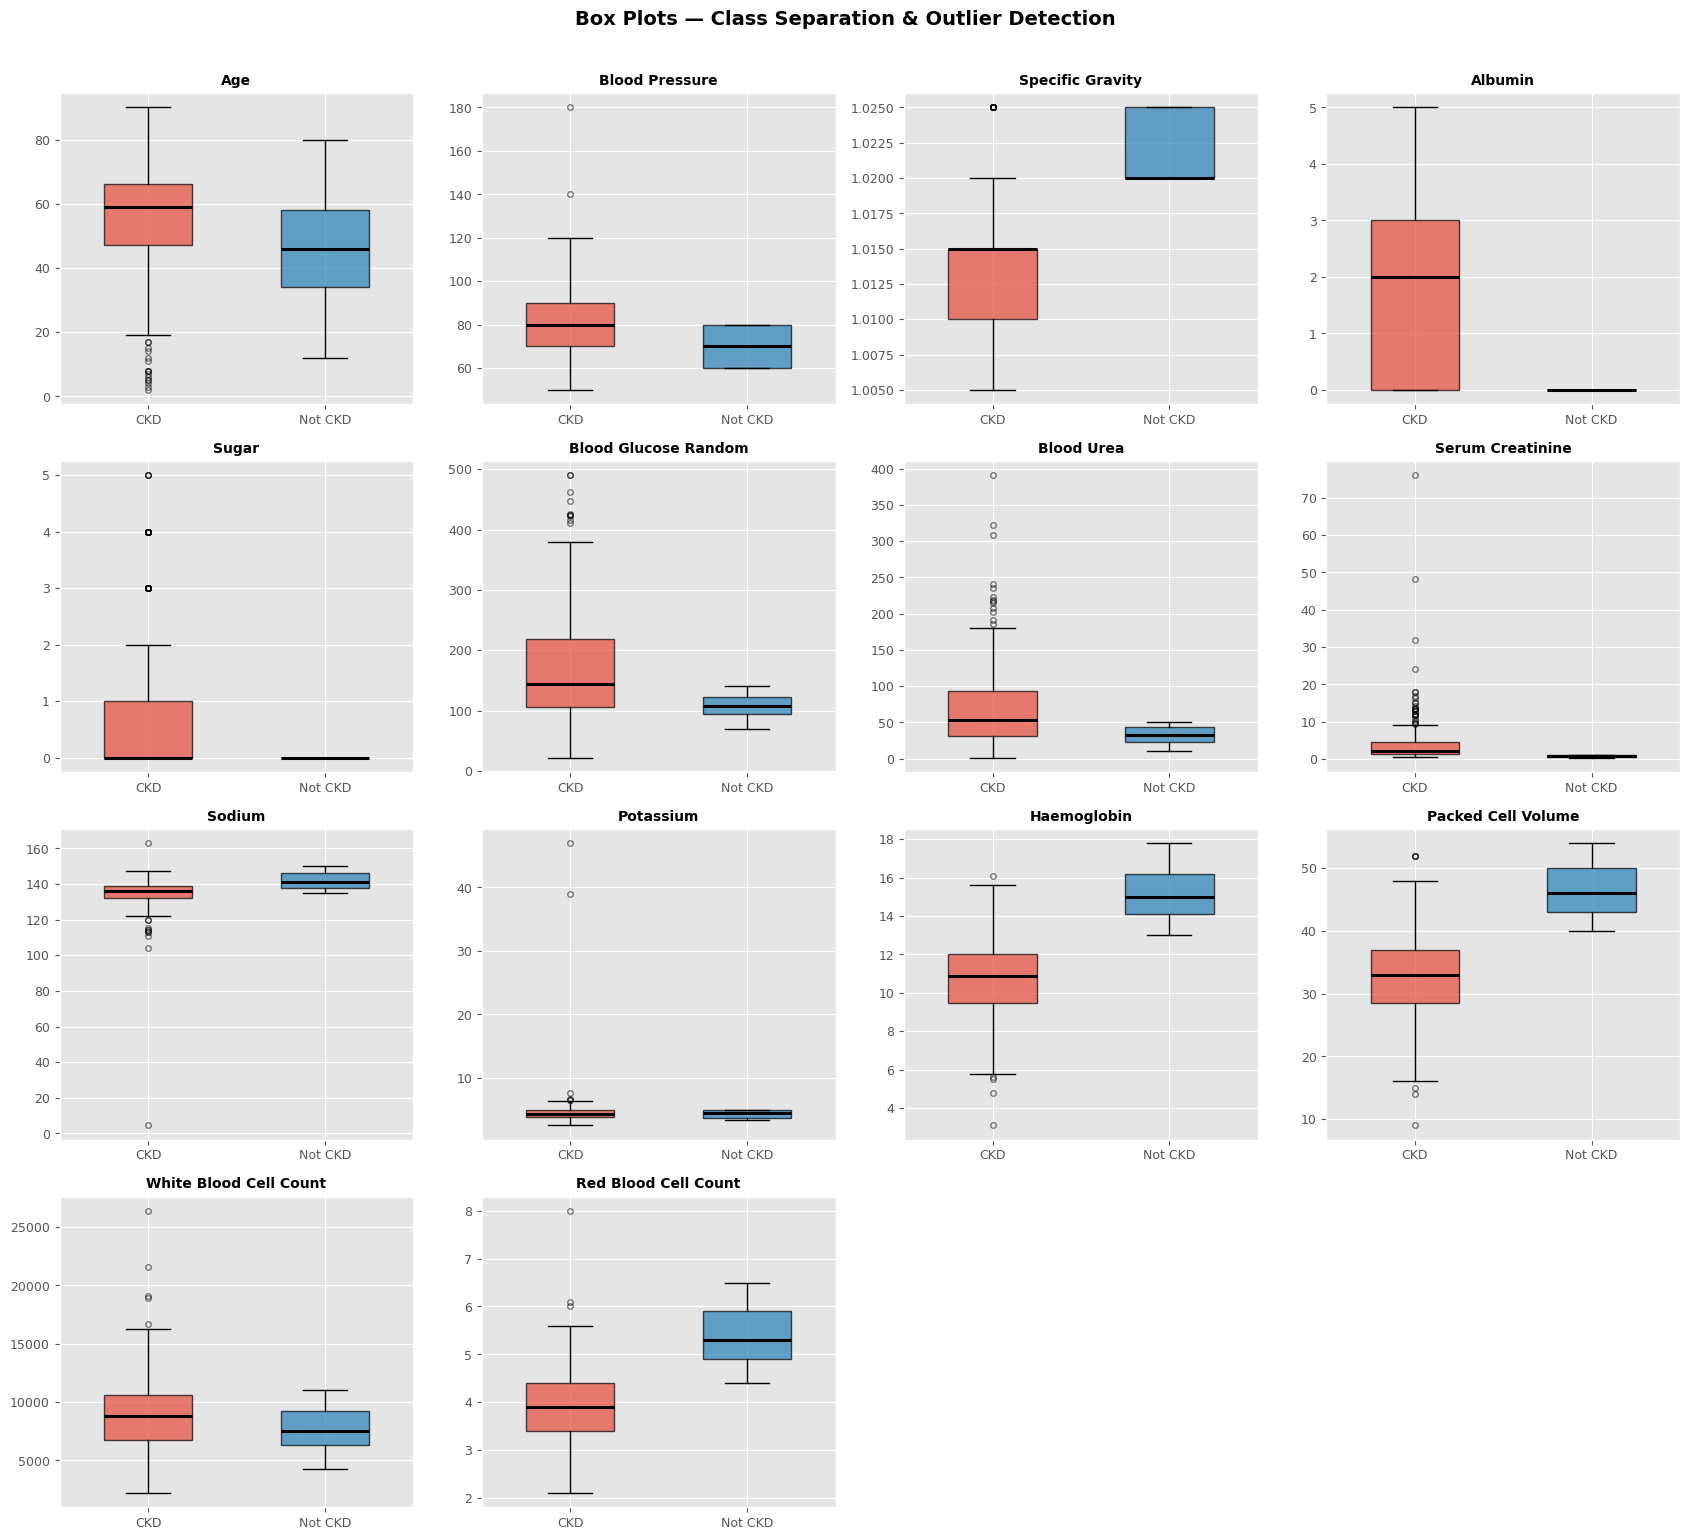

In [20]:
n_cols = 4
n_rows = -(-len(NUMERICAL_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, n_rows * 3.8))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    ckd_data    = df_plot[df_plot["_class"] == "ckd"][col].dropna()
    notckd_data = df_plot[df_plot["_class"] == "not ckd"][col].dropna()

    bp = axes[i].boxplot(
        [ckd_data, notckd_data],
        patch_artist=True,
        labels=["CKD", "Not CKD"],
        medianprops={"color": "black", "linewidth": 2.2},
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
        widths=0.5,
    )

    # Apply class colours
    bp["boxes"][0].set_facecolor(COLOR_CKD);    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor(COLOR_NOTCKD); bp["boxes"][1].set_alpha(0.7)

    axes[i].set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=9)

for j in range(len(NUMERICAL_COLS), len(axes)):
    axes[j].set_visible(False)

# Clean up temp column
df_plot.drop(columns=["_class"], inplace=True)

plt.suptitle(
    "Box Plots — Class Separation & Outlier Detection",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(VIZ_DIR / "07_boxplots_by_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 12. EDA Summary - Key Findings

These findings directly inform the decisions made in `02_Preprocessing.ipynb`.


### Dataset
| Property | Value |
|---|---|
| Shape | 400 patients × 25 features |
| Target | `class` — CKD (248) vs Not CKD (150) |
| Class ratio | 62% / 38% — mild imbalance, handled with `stratify=y` |


### Data Quality Issues Found
| Issue | Column(s) | Fix in Preprocessing |
|---|---|---|
| Tab prefix `\t` | `diabetes_mellitus`, `coronary_artery_disease` | `str.replace()` |
| Tab suffix `\t` | `class` (`ckd\t`) | `str.strip()` |
| Wrong dtype (object → float) | `packed_cell_volume`, `wc`, `rc` | `pd.to_numeric()` |
| High missingness (> 30%) | `red_blood_cells` (38%), `red_blood_cell_count` (33%) | Random-sample imputation |
| Moderate missingness | `sodium`, `potassium`, `wc` (~22%) | Random-sample imputation |
| Low missingness (< 5%) | Most other columns | Mode / random-sample imputation |


### Strongest Predictors (from KDE + correlation analysis)
| Feature | Correlation with CKD | Signal |
|---|---|---|
| `haemoglobin` | 0.769 | CKD patients have lower haemoglobin |
| `packed_cell_volume` | 0.741 | Lower in CKD |
| `specific_gravity` | 0.732 | Lower in CKD |
| `albumin` | −0.627 | Higher albumin in CKD (protein leakage) |
| `red_blood_cell_count` | 0.699 | Lower in CKD |


### Multicollinearity Alert
| Pair | Pearson r | Action |
|---|---|---|
| `haemoglobin` ↔ `packed_cell_volume` | 0.895 | Keep both — tree models handle this |
| `haemoglobin` ↔ `red_blood_cell_count` | 0.799 | Keep both |
